### K-mer Counting in Python (Sequence Complexity)

In [4]:
# A highly repetitive dummy sequence
dna_sequence = "ATGCATGCATGCGCGCGCATGC"

In [5]:
def count_kmers_beginner(sequence, k):
    """Counts k-mers using a standard loop and dictionary."""
    kmer_counts = {}
    
    # Calculate how far we can slide the window without going off the edge
    for i in range(len(sequence) - k + 1):
        
        # Slice the sequence to get the current k-mer
        kmer = sequence[i : i + k]
        
        # If we haven't seen it before, add it to the dictionary
        if kmer not in kmer_counts:
            kmer_counts[kmer] = 0
            
        # Add 1 to the count
        kmer_counts[kmer] += 1
        
    return kmer_counts

print(count_kmers_beginner(dna_sequence, k=4))

{'ATGC': 4, 'TGCA': 2, 'GCAT': 3, 'CATG': 3, 'TGCG': 1, 'GCGC': 3, 'CGCG': 2, 'CGCA': 1}


In [6]:
from collections import Counter

def count_kmers_pro(sequence, k):
    """Counts k-mers using a generator and Counter (Highly Optimized)"""
    # Create the sliding window slices and feed them directly into Counter!
    return Counter(sequence[i : i + k] for i in range(len(sequence) - k + 1))

# Let's test it looking for 3-mers!
pro_results = count_kmers_pro(dna_sequence, k=3)

print("--- Pro Results ---")
print(pro_results)

# Let's find the absolute most common 3-mer
print(f"\nMost abundant 3-mer: {pro_results.most_common(1)}")

--- Pro Results ---
Counter({'ATG': 4, 'TGC': 4, 'GCA': 3, 'CAT': 3, 'GCG': 3, 'CGC': 3})

Most abundant 3-mer: [('ATG', 4)]


### Plotting K-mer Frequencies with Matplotlib

In [9]:
import matplotlib.pyplot as plt
from collections import Counter
import random

# Our Pro K-mer function from Video 28
def count_kmers_pro(sequence, k):
    return Counter(sequence[i : i + k] for i in range(len(sequence) - k + 1))

# Let's generate a 10,000 base sequence with a heavy GC bias
bases = ['A', 'T', 'C', 'G']
weights = [0.15, 0.15, 0.35, 0.35] # Force more Cs and Gs!
crop_dna = ''.join(random.choices(bases, weights=weights, k=10000))

# Count the 3-mers
kmer_counts = count_kmers_pro(crop_dna, k=3)
print(f"Total unique 3-mers found: {len(kmer_counts)}")

Total unique 3-mers found: 64


In [10]:
# Extract the Top 10 most common K-mers
top_10 = kmer_counts.most_common(10)
print(top_10)

[('CCC', 450), ('GGG', 443), ('CGC', 431), ('GCC', 422), ('CCG', 407), ('GGC', 406), ('CGG', 396), ('GCG', 396), ('CAC', 216), ('TGG', 208)]


In [11]:
# Split the tuples into X (labels) and Y (values)
kmer_labels = [item[0] for item in top_10]
kmer_values = [item[1] for item in top_10]

print(f"Labels: {kmer_labels}")
print(f"Values: {kmer_values}")

Labels: ['CCC', 'GGG', 'CGC', 'GCC', 'CCG', 'GGC', 'CGG', 'GCG', 'CAC', 'TGG']
Values: [450, 443, 431, 422, 407, 406, 396, 396, 216, 208]


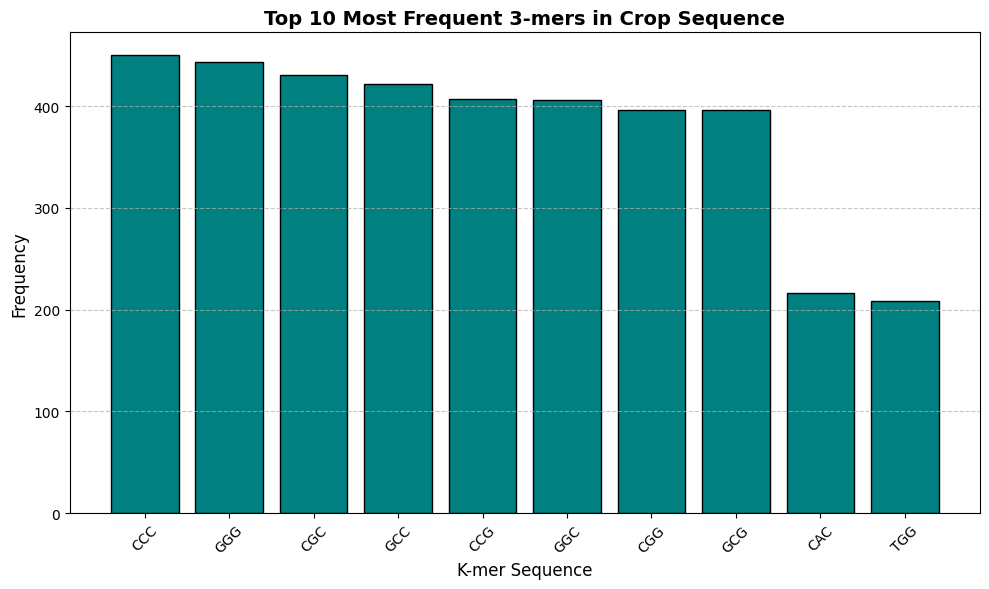

In [12]:
# 1. Set the figure size
plt.figure(figsize=(10, 6))

# 2. Create the Bar Chart
# We use a nice teal color and add a black edge for crispness
plt.bar(kmer_labels, kmer_values, color='teal', edgecolor='black')

# 3. Add Titles and Labels
plt.title("Top 10 Most Frequent 3-mers in Crop Sequence", fontsize=14, fontweight='bold')
plt.xlabel("K-mer Sequence", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# 4. Polish the X-axis
# If you use longer K-mers (like 6-mers), the text will overlap. 
# Rotating the labels 45 degrees is a crucial pro-tip!
plt.xticks(rotation=45)

# Add a subtle grid behind the bars
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot!
plt.tight_layout() # Ensures nothing gets cut off
plt.show()